In [1]:
import pandas as pd
import random
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
spam_emails = [
    "CONGRATULATIONS!!! You WON $50,000 in 2026!!! Click NOW @#$%",
    "URGENT!!! Claim your FREE iPhone 15 NOW!!!",
    "You have WON Rs.1,00,000!!! Send bank details ASAP!!!",
    "CLICK HERE!!! Get 90% DISCOUNT today @ www.offer.com",
    "FREE!!! FREE!!! FREE!!! Claim your GIFT now!!!",
    "Earn $5000 per DAY!!! Work from HOME @#$%",
    "WINNER!!! Your mobile number won a PRIZE!!!",
    "LIMITED OFFER!!! Buy NOW & Get 80% OFF!!!",
    "Congratulations!!! You are the LUCKY WINNER!!!",
    "URGENT!!! Your account will EXPIRE in 24 HOURS!!!",
    "Get RICH quickly!!! Invest Rs.5000 & Earn Rs.50,000!!!",
    "FREE VACATION!!! Click www.fakeoffer.com NOW!!!",
    "You WON a brand new CAR!!! Call NOW!!!",
    "SPECIAL OFFER!!! Only Rs.99 for TODAY!!!",
    "CLAIM YOUR REWARD!!! Offer expires TODAY!!!",
    "100% FREE MONEY!!! No investment required!!!",
    "ACT NOW!!! This AMAZING offer ends in 2 HOURS!!!",
    "You are SELECTED!!! Get your FREE laptop!!!",
    "Lottery WINNER!!! Send your ACCOUNT number NOW!!!",
    "BUY NOW!!! Get 5 products for the price of 1!!!"
]

In [3]:
ham_emails = [
    "Hi Shuva, please attend the MEETING at 10:30 AM tomorrow.",
    "Your Assignment #4 is due on 15/07/2026.",
    "Please send the PROJECT report before 5:00 PM!!!",
    "Hello!!! Can we schedule a meeting for Friday @ 2 PM?",
    "Your interview is scheduled on 20/07/2026 at 11:00 AM.",
    "Please review the attached FILE & share your feedback.",
    "The CLASS has been moved to Room #204.",
    "Reminder: Pay the college fee before Monday.",
    "Your ORDER #12345 has been successfully delivered!!!",
    "Hi Shuva!!! Are you available for the project discussion today?",
    "The exam will start at 9:30 AM on 25/07/2026.",
    "Please call me after the class.",
    "Your attendance is 85% for this semester.",
    "Meeting Location: Block-A, Room #305.",
    "Please submit the PDF file before 11:59 PM!!!",
    "Hello Shuva!!! Your leave request has been APPROVED.",
    "The presentation is scheduled for 3:00 PM @ Lab-2.",
    "Your marks are: Python=85, ML=90, DBMS=88.",
    "Please check www.collegeportal.com for the timetable.",
    "Project Meeting!!! Tomorrow @ 10 AM in Room #101."
]

In [4]:
random.seed(42)

data = []

for i in range(1000):

    # 50% spam and 50% ham
    if i < 500:

        # 85% correct spam emails
        if random.random() < 0.85:
            email = random.choice(spam_emails)
        else:
            # 15% confusing normal-looking emails
            email = random.choice(ham_emails)

        label = "spam"

    else:

        # 85% correct ham emails
        if random.random() < 0.85:
            email = random.choice(ham_emails)
        else:
            # 15% confusing spam-looking emails
            email = random.choice(spam_emails)

        label = "ham"

    data.append([email, label])

In [5]:
df = pd.DataFrame(
    data,
    columns=["Email", "Label"]
)

# Shuffle all rows randomly
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.head(10)

,Email,Label
0,Your ORDER #12345 has been successfully delive...,ham
1,Project Meeting!!! Tomorrow @ 10 AM in Room #101.,ham
2,Reminder: Pay the college fee before Monday.,ham
3,Please submit the PDF file before 11:59 PM!!!,ham
4,Get RICH quickly!!! Invest Rs.5000 & Earn Rs.5...,spam
5,Your interview is scheduled on 20/07/2026 at 1...,ham
6,"Your marks are: Python=85, ML=90, DBMS=88.",ham
7,Your Assignment #4 is due on 15/07/2026.,ham
8,Please review the attached FILE & share your f...,ham
9,Lottery WINNER!!! Send your ACCOUNT number NOW!!!,spam


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 2)


In [7]:
df["Label"].value_counts()

,count
Label,
ham,500
spam,500


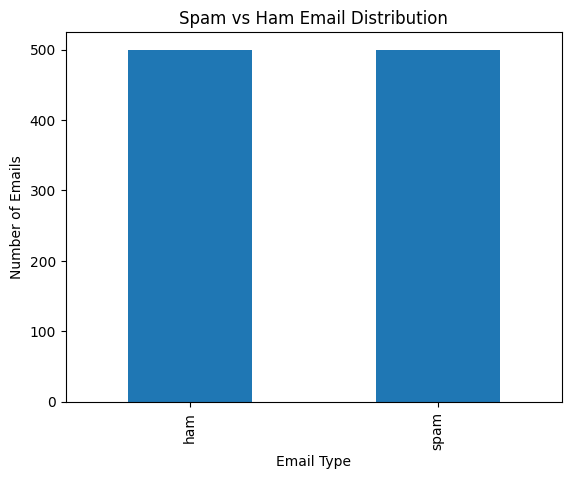

In [8]:
df["Label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.show()

In [9]:
df.isnull().sum()

,0
Email,0
Label,0


In [10]:
df.duplicated().sum()

np.int64(922)

In [11]:
def clean_text(text):

    # Convert uppercase letters to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'www\.\S+|https?://\S+', '', text)

    # Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [12]:
df["Clean_Email"] = df["Email"].apply(clean_text)

df.head(10)

,Email,Label,Clean_Email
0,Your ORDER #12345 has been successfully delive...,ham,your order has been successfully delivered
1,Project Meeting!!! Tomorrow @ 10 AM in Room #101.,ham,project meeting tomorrow am in room
2,Reminder: Pay the college fee before Monday.,ham,reminder pay the college fee before monday
3,Please submit the PDF file before 11:59 PM!!!,ham,please submit the pdf file before pm
4,Get RICH quickly!!! Invest Rs.5000 & Earn Rs.5...,spam,get rich quickly invest rs earn rs
5,Your interview is scheduled on 20/07/2026 at 1...,ham,your interview is scheduled on at am
6,"Your marks are: Python=85, ML=90, DBMS=88.",ham,your marks are python ml dbms
7,Your Assignment #4 is due on 15/07/2026.,ham,your assignment is due on
8,Please review the attached FILE & share your f...,ham,please review the attached file share your fee...
9,Lottery WINNER!!! Send your ACCOUNT number NOW!!!,spam,lottery winner send your account number now


In [13]:
for i in range(5):

    print("Original Email:")
    print(df["Email"].iloc[i])

    print("\nCleaned Email:")
    print(df["Clean_Email"].iloc[i])

    print("-" * 70)

Original Email:
Your ORDER #12345 has been successfully delivered!!!

Cleaned Email:
your order has been successfully delivered
----------------------------------------------------------------------
Original Email:
Project Meeting!!! Tomorrow @ 10 AM in Room #101.

Cleaned Email:
project meeting tomorrow am in room
----------------------------------------------------------------------
Original Email:
Reminder: Pay the college fee before Monday.

Cleaned Email:
reminder pay the college fee before monday
----------------------------------------------------------------------
Original Email:
Please submit the PDF file before 11:59 PM!!!

Cleaned Email:
please submit the pdf file before pm
----------------------------------------------------------------------
Original Email:
Get RICH quickly!!! Invest Rs.5000 & Earn Rs.50,000!!!

Cleaned Email:
get rich quickly invest rs earn rs
----------------------------------------------------------------------


In [14]:
X = df["Clean_Email"]
y = df["Label"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("Training Emails:", len(X_train))
print("Testing Emails :", len(X_test))

Training Emails: 800
Testing Emails : 200


In [17]:
tfidf = TfidfVectorizer(
    stop_words="english"
)

In [18]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [19]:
print("Training TF-IDF Shape:", X_train_tfidf.shape)

print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (800, 102)
Testing TF-IDF Shape: (200, 102)


In [20]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [21]:
y_pred = model.predict(X_test_tfidf)

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Model Accuracy: 85.0 %


In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")

print(cm)

Confusion Matrix:
[[86 14]
 [16 84]]


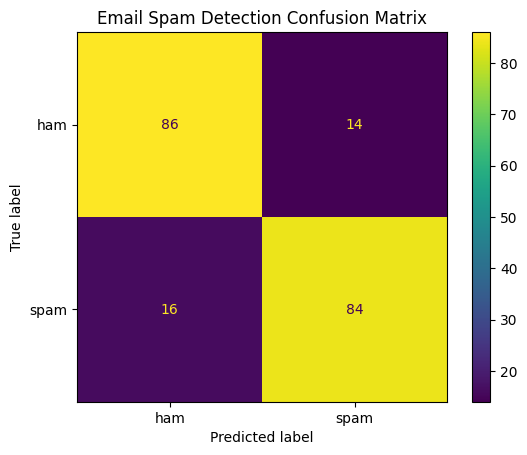

In [24]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
).plot()

plt.title("Email Spam Detection Confusion Matrix")

plt.show()

In [25]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

         ham       0.84      0.86      0.85       100
        spam       0.86      0.84      0.85       100

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



In [26]:
total_emails = len(df)

total_spam = (df["Label"] == "spam").sum()

total_ham = (df["Label"] == "ham").sum()

spam_percentage = (
    total_spam / total_emails
) * 100

ham_percentage = (
    total_ham / total_emails
) * 100

model_accuracy = accuracy * 100

In [27]:
print("=" * 60)

print("          EMAIL SPAM DETECTION ANALYSIS REPORT")

print("=" * 60)


print("\n1. DATASET ANALYSIS")

print("-" * 60)

print("Total Emails          :", total_emails)

print("Total Spam Emails     :", total_spam)

print("Total Ham Emails      :", total_ham)

print(
    "Spam Percentage       :",
    round(spam_percentage, 2),
    "%"
)

print(
    "Ham Percentage        :",
    round(ham_percentage, 2),
    "%"
)


print("\n2. PREPROCESSING ANALYSIS")

print("-" * 60)

print("Text converted to lowercase")

print("URLs removed")

print("Numbers removed")

print("Special characters removed")

print("Extra spaces removed")


print("\n3. MODEL INFORMATION")

print("-" * 60)

print("Model Used            : Multinomial Naive Bayes")

print("Feature Extraction    : TF-IDF")

print("Training Emails       :", len(X_train))

print("Testing Emails        :", len(X_test))


print("\n4. MODEL PERFORMANCE")

print("-" * 60)

print(
    "Model Accuracy        :",
    round(model_accuracy, 2),
    "%"
)


print("\n5. FINAL ANALYSIS")

print("-" * 60)


if 80 <= model_accuracy <= 90:

    print(
        "The model achieved good accuracy "
        "between 80% and 90%."
    )

elif model_accuracy > 90:

    print(
        "The model achieved very high accuracy."
    )

else:

    print(
        "The model needs further improvement."
    )


print("\n" + "=" * 60)

print("                 END OF ANALYSIS REPORT")

print("=" * 60)

          EMAIL SPAM DETECTION ANALYSIS REPORT

1. DATASET ANALYSIS
------------------------------------------------------------
Total Emails          : 1000
Total Spam Emails     : 500
Total Ham Emails      : 500
Spam Percentage       : 50.0 %
Ham Percentage        : 50.0 %

2. PREPROCESSING ANALYSIS
------------------------------------------------------------
Text converted to lowercase
URLs removed
Numbers removed
Special characters removed
Extra spaces removed

3. MODEL INFORMATION
------------------------------------------------------------
Model Used            : Multinomial Naive Bayes
Feature Extraction    : TF-IDF
Training Emails       : 800
Testing Emails        : 200

4. MODEL PERFORMANCE
------------------------------------------------------------
Model Accuracy        : 85.0 %

5. FINAL ANALYSIS
------------------------------------------------------------
The model achieved good accuracy between 80% and 90%.

                 END OF ANALYSIS REPORT


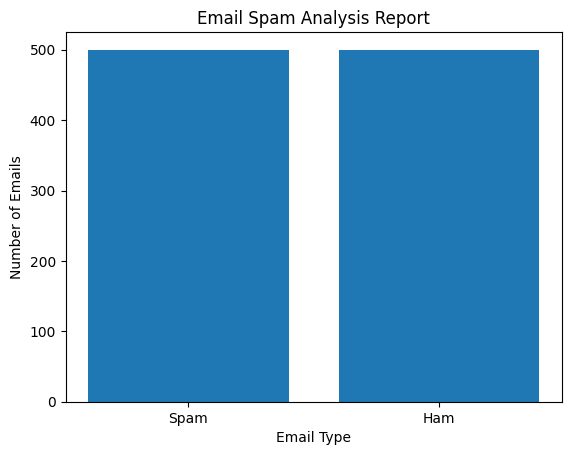

In [28]:
report_data = pd.DataFrame({
    "Email Type": ["Spam", "Ham"],
    "Count": [total_spam, total_ham]
})

plt.bar(
    report_data["Email Type"],
    report_data["Count"]
)

plt.title("Email Spam Analysis Report")

plt.xlabel("Email Type")

plt.ylabel("Number of Emails")

plt.show()

In [29]:
def predict_email(email):

    # Clean the email
    cleaned_email = clean_text(email)

    # Convert into TF-IDF
    email_tfidf = tfidf.transform(
        [cleaned_email]
    )

    # Predict
    prediction = model.predict(
        email_tfidf
    )[0]

    return prediction

In [30]:
new_email = """
CONGRATULATIONS!!!
You WON $100,000!!!
Click NOW!!!
"""

prediction = predict_email(new_email)

print("Email      :", new_email)

print("Prediction :", prediction)

Email      : 
CONGRATULATIONS!!!
You WON $100,000!!!
Click NOW!!!

Prediction : spam


In [31]:
new_email = """
Hi Shuva,
please attend the project meeting
tomorrow at 10 AM.
"""

prediction = predict_email(new_email)

print("Email      :", new_email)

print("Prediction :", prediction)

Email      : 
Hi Shuva,
please attend the project meeting
tomorrow at 10 AM.

Prediction : ham
